In [1]:
%load_ext autoreload
%autoreload 2

In [22]:
import os
import numpy as np
import torch
import torch.nn as nn
import gc
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset, TensorDataset
from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedRNN
from bioplnn.utils import (
    initialize_dataloader,
    initialize_scheduler,
    manual_seed,
)
from collections import deque
from umap import UMAP
import copy

from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.cm import get_cmap

import pickle
import matplotlib.pyplot as plt
checkpoint_path = "./train/checkpoints/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

In [41]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20
        
    try:
        if full_cfg["model_type"] == "cnn":
            model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
            classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        else:
            model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
            classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    except:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)

        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg

def get_activations(model, classifier, num_samples, loader, decision_step, num_steps=20, dim=48, device=None):
    if device is None:
        device = next(model.parameters()).device

    # choose a subset of indices
    all_indices = np.arange(len(loader.dataset))
    subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)

    # wrap dataset
    subset_dataset = Subset(loader.dataset, subset_indices)

    # mirror original loader settings where possible
    dataloader = DataLoader(
        subset_dataset,
        batch_size=loader.batch_size,
        shuffle=False,  # keep consistent ordering for preallocation fill
        num_workers=getattr(loader, "num_workers", 0),
        pin_memory=getattr(loader, "pin_memory", False),
        drop_last=False
    )

    # preallocate
    e_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
    i_a = np.zeros((num_samples, num_steps, 4, dim, dim), dtype=np.float32)
    o_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    model.eval()
    classifier.eval()
    classifier.to(device)

    sample_idx = 0
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            bsz = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device, non_blocking=True)

            # core model forward once
            batch_output_states, batch_neuron_states, batch_feedback_states = model(
                batch_inputs, num_steps=num_steps
            )

            # --- collect O ---
            # your original code: batch_output_states[0] (shape: [B, T, 8, H, W])
            o = batch_output_states[0].detach().cpu().numpy()  # (B, T, 8, dim, dim)

            # --- collect E and I via query_neuron_states ---
            # your original code: query_neuron_states(states, layer_idx, 0 for 'e', 1 for 'i')
            e = model.query_neuron_states(batch_neuron_states, 0, 0).detach().cpu().numpy()  # (B, T, 8, dim, dim)
            i_ = model.query_neuron_states(batch_neuron_states, 0, 1).detach().cpu().numpy() # (B, T, 4, dim, dim)

            # --- decisions in the same pass ---
            # your original code called classifier(batch_inputs, num_steps=decision_step) and argmax over last dim
            pred = classifier(batch_inputs, num_steps=decision_step)            # (B, num_classes) or similar
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()            # (B,)

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            e_a[sl, :, :, :, :] = e
            i_a[sl, :, :, :, :] = i_
            o_a[sl, :, :, :, :] = o
            decisions[sl] = dec

            sample_idx += bsz

    return e_a, i_a, o_a, decisions, dataloader


def compute_wall_mask(maze):
    """
    maze: 2D np.array of shape (48,48), 1=corridor, 0=wall
    returns: same shape, dtype=uint8
    """
    return (maze == 1).astype(np.uint8)

def compute_distance_map(maze, start_goal):
    """
    maze: 2D array 1=corridor, 0=wall
    start_goal: 2D binary array, 1 at the two points, 0 elsewhere
    returns: 2D int array where each cell = shortest-path distance (in steps)
             to the nearest start/goal; walls get a large value or np.inf.
    """
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    q = deque()

    # initialize BFS frontier at both points
    for (i, j), val in np.ndenumerate(start_goal):
        if val == 1:
            dist[i, j] = 0
            q.append((i, j))

    # 4‐connected neighbors
    neighbors = [(1,0),(-1,0),(0,1),(0,-1)]

    while q:
        i, j = q.popleft()
        for di, dj in neighbors:
            ii, jj = i + di, j + dj
            if 0 <= ii < H and 0 <= jj < W:
                # only traverse corridors
                if maze[ii, jj] == 1 and dist[ii, jj] == np.inf:
                    dist[ii, jj] = dist[i, j] + 1
                    q.append((ii, jj))
    return dist

def map_distances(maze, start_goal, radius=2):
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    maze2 = maze.copy()
    q = deque()

    # seed from input blocks
    for (i,j), v in np.ndenumerate(start_goal):
        if v:
            dist[i,j] = 0
            maze2[i,j] = 1
            q.append((i,j))

    # all offsets in a (2*radius+1)^2 patch, excluding (0,0)
    nbrs = [(dx,dy)
            for dx in range(-radius, radius+1)
            for dy in range(-radius, radius+1)
            if not (dx==0 and dy==0)]

    while q:
        i, j = q.popleft()
        dnext = dist[i, j] + 1
        for dx, dy in nbrs:
            ii, jj = i + dx, j + dy
            if not (0 <= ii < H and 0 <= jj < W): 
                continue
            if maze2[ii, jj] != 1:
                continue

            # only block if both orthogonal neighbors are walls
            if dx != 0 and dy != 0:
                if maze2[i+dx, j] == 0 and maze2[i, j+dy] == 0:
                    continue

            if dist[ii, jj] == np.inf:
                dist[ii, jj] = dnext
                q.append((ii, jj))

    return dist

def bfs_distance(maze, seeds):
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    q = deque()

    # allow BFS to traverse the seeds even if maze[...] == 0
    maze2 = maze.copy()
    for (i, j) in seeds:
        dist[i, j] = 0
        maze2[i, j] = 1
        q.append((i, j))

    nbrs = [(1,0),(-1,0),(0,1),(0,-1)]
    while q:
        i, j = q.popleft()
        for di, dj in nbrs:
            ii, jj = i+di, j+dj
            if 0 <= ii < H and 0 <= jj < W:
                if maze2[ii, jj] == 1 and dist[ii, jj] == np.inf:
                    dist[ii, jj] = dist[i, j] + 1
                    q.append((ii, jj))
    return dist

def get_start_coordinates(maze, start_goal):
    H, W = maze.shape

    # 1) Flood-fill start_goal into two blocks
    visited = np.zeros_like(start_goal, bool)
    blocks = []
    for (i,j), v in np.ndenumerate(start_goal):
        if v and not visited[i,j]:
            comp, q = [], deque([(i,j)])
            visited[i,j] = True
            while q:
                x,y = q.popleft()
                comp.append((x,y))
                for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                    nx, ny = x+dx, y+dy
                    if (0<=nx<H and 0<=ny<W and start_goal[nx,ny]
                        and not visited[nx,ny]):
                        visited[nx,ny] = True
                        q.append((nx,ny))
            blocks.append(comp)
    
    return blocks

def compute_shortest_path_mask(maze, start_goal):
    """
    Returns an (H,W) uint8 mask marking corridor cells on any shortest path
    between the two 2×2 input blocks. If the blocks are disconnected, returns
    all zeros.
    """
    H, W = maze.shape

    blocks = get_start_coordinates(maze, start_goal)
    
    if len(blocks) != 2:
        raise ValueError("Expected exactly two disjoint 2×2 blocks in start_goal.")

    # 2) BFS distances from each block
    dist0 = bfs_distance(maze, blocks[0])
    dist1 = bfs_distance(maze, blocks[1])

    # 3) Minimal distance between blocks
    d_min = min(dist0[i,j] for (i,j) in blocks[1])

    # 4) If infinite, no path exists → return zero mask
    if np.isinf(d_min):
        return np.zeros((H, W), dtype=np.uint8)

    # 5) Mark cells where dist0 + dist1 == d_min and are corridors
    sp = ((dist0 + dist1) == d_min) & (maze == 1)
    return sp.astype(np.uint8)

def compute_reachable_mask(maze, start_goal, t):
    """
    All cells reachable within t conv‐hops.
    """
    dist_map = map_distances(maze, start_goal)
    return (dist_map <= t).astype(np.uint8)

def compute_frontier_shell(maze, start_goal, t):
    """
    Cells reached *exactly* on hop t.
    """
    dist_map = map_distances(maze, start_goal)
    return (dist_map == t).astype(np.uint8)

def compute_articulation_points(maze, start_goal):
    """
    Binary map of corridor‐cells whose removal disconnects the two input blocks.
    Brute‐force: for each corridor cell, zero it out and test connectivity.
    """
    H, W = maze.shape
    # find the two blocks again
    visited = np.zeros_like(start_goal, bool)
    blocks = []
    for (i,j), v in np.ndenumerate(start_goal):
        if v and not visited[i,j]:
            comp = []
            q = deque([(i,j)])
            visited[i,j] = True
            while q:
                x,y = q.popleft()
                comp.append((x,y))
                for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                    nx, ny = x+dx, y+dy
                    if 0<=nx<H and 0<=ny<W and start_goal[nx,ny] and not visited[nx,ny]:
                        visited[nx,ny] = True
                        q.append((nx,ny))
            blocks.append(comp)
    assert len(blocks)==2

    def connected_without(rem_i, rem_j):
        """Test if block0 can reach block1 when (rem_i,rem_j) is treated as wall."""
        seen = np.zeros((H,W), bool)
        q = deque()
        # seed from block0, but skip if removing that cell
        for (i,j) in blocks[0]:
            if (i,j)!=(rem_i,rem_j):
                seen[i,j] = True
                q.append((i,j))
        while q:
            i,j = q.popleft()
            if (i,j) in blocks[1]:
                return True
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ii,jj = i+di, j+dj
                if 0<=ii<H and 0<=jj<W and not seen[ii,jj]:
                    if (ii,jj)==(rem_i,rem_j):
                        continue
                    if maze[ii,jj]==1 or start_goal[ii,jj]:
                        seen[ii,jj] = True
                        q.append((ii,jj))
        return False

    art_map = np.zeros((H,W), np.uint8)
    for (i,j), v in np.ndenumerate(maze):
        if v==1 and not start_goal[i,j]:
            if not connected_without(i,j):
                art_map[i,j] = 1
    return art_map

def compute_node_degree(maze, start_goal):
    """
    For each corridor cell, count 4‐connected corridor neighbors.
    """
    H, W = maze.shape
    deg = np.zeros((H,W), int)
    for (i,j), v in np.ndenumerate(maze):
        if v==1:
            cnt = 0
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ii, jj = i+di, j+dj
                if 0<=ii<H and 0<=jj<W and maze[ii,jj]==1:
                    cnt += 1
            deg[i,j] = cnt
    return deg

def compute_reachable_node_degree(maze, start_goal):
    """
    For each corridor cell, count 4‐connected corridor neighbors.
    """
    reachable = compute_reachable_mask(maze, start_goal, 100)
    H, W = maze.shape
    deg = np.zeros((H,W), int)
    for (i,j), v in np.ndenumerate(maze):
        if v==1:
            cnt = 0
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ii, jj = i+di, j+dj
                if 0<=ii<H and 0<=jj<W and reachable[ii,jj]==1:
                    cnt += 1
            deg[i,j] = cnt
    return deg

def bresenham_line(x0, y0, x1, y1):
    """
    Bresenham’s line algorithm between two integer points (x0,y0)->(x1,y1).
    Returns list of (x,y) coordinates on the line.
    """
    pts = []
    dx = abs(x1-x0)
    dy = abs(y1-y0)
    x, y = x0, y0
    sx = 1 if x1>x0 else -1
    sy = 1 if y1>y0 else -1
    if dx > dy:
        err = dx/2.0
        while x != x1:
            pts.append((x,y))
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
    else:
        err = dy/2.0
        while y != y1:
            pts.append((x,y))
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy
    pts.append((x1,y1))
    return pts

def compute_euclidean_los_mask(maze, start_goal):
    """
    Binary mask: for each corridor cell (i,j), 1 if there exists at least one
    straight (Bresenham) line to any input cell that passes only through
    corridors or input cells.
    """
    H, W = maze.shape
    los = np.zeros((H,W), np.uint8)
    # list all target coords
    targets = [(i,j) for (i,j),v in np.ndenumerate(start_goal) if v]
    for (i,j), v in np.ndenumerate(maze):
        if v != 1:
            continue
        for (ti,tj) in targets:
            line = bresenham_line(i,j, ti,tj)
            if all(maze[x,y]==1 or start_goal[x,y]==1 for (x,y) in line):
                los[i,j] = 1
                break
    return los

def both_reachable_mask(maze, start_goal, t):
    """
    Return a mask where cells are True iff reachable within ≤ t steps
    from both start1 and start2 using the existing reachable_mask.
    """
    start_coordinates = get_start_coordinates(maze, start_goal)
    
    start1 = np.zeros_like(start_goal)
    for row, col in start_coordinates[0]:
        start1[row,col] = 1

    start2 = np.zeros_like(start_goal)
    try:
        for row, col in start_coordinates[1]:
            start2[row,col] = 1
    except:
        for row, col in start_coordinates[0]:
            start2[row,col] = 1

    reach_start1 = compute_reachable_mask(maze, start1, t=t)
    reach_start2 = compute_reachable_mask(maze, start2, t=t)

    return reach_start1 & reach_start2

def to_target(d, tau):             # d: [N,H,W], with +inf allowed
    y = torch.exp(-d / tau)        # or 1/(1+d/tau)
    y[~torch.isfinite(d)] = 0.0    # unreachable -> 0
    return y

def to_distance(y, tau, eps=1e-6):
    y = torch.clamp(y, min=eps)
    return -tau * torch.log(y)     # or tau*(1/y - 1)
    
def get_feature_map(dataloader, feature_map_func, time_dependent, num_steps, dim):
    num_samples = len(dataloader.dataset)
    if time_dependent:  
        feature_map = np.zeros((num_samples, num_steps, dim, dim))
    else:
        feature_map = np.zeros((num_samples, dim, dim))

    sample_idx = 0
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            for input in batch_inputs:
                maze = np.array(input[0])
                start_points = np.array(input[-1])
                if time_dependent: 
                    for t in range(num_steps):
                        map = feature_map_func(maze, start_points, t=t)
                        feature_map[sample_idx, t] = map
                else:
                    map = feature_map_func(maze, start_points)
                    feature_map[sample_idx] = map

                sample_idx += 1 
    return feature_map

In [4]:
## CORRELATED DOTS ##

# wandb_name, checkpoint = "fancy-silence-24", 370 #BIOPLNN
# wandb_name, checkpoint = "glowing-deluge-31", 330 #CNN

## MAZES ##

wandb_name, checkpoint = "golden-universe-515", 320 # ReLU, with I->I recurrence

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg = load_model_and_config(wandb_name, checkpoint_path)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

/tmp/ipykernel_2886825/2472067699.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (0->1): Sequential(
            (0): Conv2d(4, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
       

In [5]:
batch_size = 512
num_train_samples = batch_size * 3
num_test_samples = batch_size

#MAZES

dim = 48
num_steps = 20
decision_step = 20
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)

# DOTS

# n_frames = 40
# resolution = (128, 128)
# correlation = (0.25,0.75)
# max_speed = 1
# train_loader, test_loader = initialize_dataloader(
#         seed=12, dataset="correlated_dots",
#         resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=num_samples,
#         batch_size=batch_size)
# decision_step = n_frames
# num_steps = n_frames
# dim = resolution[0]

# DOTS GOING ONE DIRECTION

#NEED TO FIGURE OUT WTF IS GOING ON HERE
# label_to_keep = [0,1,2,3,4,5,6,7]
# train_loader = keep_only_label_from_loader(train_loader, label_to_keep)
# num_samples = len(train_loader.dataset)

train_ea, train_ia, train_oa, train_decisions, trainloader = get_activations(model, classifier, num_train_samples, train_loader, decision_step, num_steps=num_steps,dim=dim)
test_ea, test_ia, test_oa, test_decisions, testloader = get_activations(model, classifier, num_test_samples, test_loader, decision_step, num_steps=num_steps,dim=dim)

100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


In [ ]:
dist_map = map_distances(maze, start_goal)
reach_map = compute_reachable_mask(dist_map, t=3)  
both_reachable = both_reachable_mask(maze, start_goal, t=20)
sp_mask = compute_shortest_path_mask(maze, start_goal)
shell3   = compute_frontier_shell(dist_map, t=0)
deg_map  = compute_node_degree(maze)
los_map  = compute_euclidean_los_mask(maze, start_goal)

In [145]:
train_fm = get_feature_map(trainloader, compute_frontier_shell, True, num_steps, dim)
test_fm = get_feature_map(testloader, compute_frontier_shell, True, num_steps, dim)

  0%|          | 0/3 [00:00<?, ?it/s]/tmp/ipykernel_2886825/1578341414.py:490: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  maze = np.array(input[0])
/tmp/ipykernel_2886825/1578341414.py:491: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  start_points = np.array(input[-1])
100%|██████████| 1/1 [00:35<00:00, 35.44s/it]


In [146]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class LinearReadout3D(nn.Module):
    def __init__(self, C, T, kH=3, kW=3):
        super().__init__()
        self.conv = nn.Conv3d(C, 1, kernel_size=(T,kH,kW), padding=(0,kH//2,kW//2), bias=True)
    def forward(self, x):                 # x: [B,T,C,H,W]
        x = x.permute(0,2,1,3,4)          # -> [B,C,T,H,W]
        return self.conv(x).squeeze(2)    # [B,1,H,W]

# ---------- loss helpers ----------
def make_masked_mse():
    def loss(pred, target):               # pred/target: [B,1,H,W]
        mask = torch.isfinite(target)
        if not mask.any(): return pred.sum()*0
        return ((pred - target)[mask]**2).mean()
    return loss

# ---------- training ----------
def train_readout(train_X, train_y, val_X, val_y, loss_fn,
                  target_transform=lambda y: y, epochs=50, lr=1e-3, bs=128, kH=3, kW=3,
                  patience=5, min_delta=0.0):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    N,T,C,H,W = train_X.shape
    model = LinearReadout3D(C, T, kH, kW).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    y_train = target_transform(train_y).float()
    y_val   = target_transform(val_y).float()
    tr = DataLoader(TensorDataset(train_X.float(), y_train), batch_size=bs, shuffle=True)
    va = DataLoader(TensorDataset(val_X.float(),   y_val),   batch_size=bs)

    best = float('inf'); best_state = None; bad = 0
    for ep in range(epochs):
        model.train()
        for Xb, yb in tr:
            Xb = torch.nan_to_num(Xb).to(device)
            yb = yb.to(device).unsqueeze(1)
            pred = model(Xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()

        model.eval(); vloss = 0.0; n = 0
        with torch.no_grad():
            for Xb, yb in va:
                Xb = torch.nan_to_num(Xb).to(device)
                yb = yb.to(device).unsqueeze(1)
                vloss += loss_fn(model(Xb), yb).item(); n += 1
        v = vloss / max(n, 1)
        print(f"Epoch {ep+1}: val_loss={v:.6f}")

        if v + min_delta < best:
            best, best_state, bad = v, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping at epoch {ep+1} (best={best:.6f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# ---------- inference ----------
def predict_map(model, sample):           # sample: [T,C,H,W] or [1,T,C,H,W]
    model.eval()
    with torch.no_grad():
        if sample.ndim == 4: sample = sample.unsqueeze(0)
        pred = model(torch.nan_to_num(sample.float()).to(next(model.parameters()).device))
    return pred[0,0].cpu()                # [H,W]

def eval_iou_dice(model, X, y01, batch_size=8, thresh=0.5):
    device = next(model.parameters()).device
    dl = DataLoader(TensorDataset(X.float(), y01.float()), batch_size=batch_size)
    model.eval()
    inter_sum = union_sum = 0.0
    iou_macros, dice_macros = [], []
    with torch.no_grad():
        for Xb, Yb in dl:
            Xb = torch.nan_to_num(Xb).to(device)
            Yb = (Yb > 0.5).to(device)                       # [B,H,W] bool
            Pb = (torch.sigmoid(model(Xb).squeeze(1)) >= thresh)  # [B,H,W] bool

            inter = (Pb & Yb).sum((1,2)).float()
            union = (Pb | Yb).sum((1,2)).float()
            iou   = torch.where(union>0, inter/union, torch.ones_like(union))
            dice  = torch.where(
                (Pb.sum((1,2))+Yb.sum((1,2)))>0,
                2*inter/(Pb.sum((1,2))+Yb.sum((1,2))),
                torch.ones_like(inter)
            )

            iou_macros.append(iou); dice_macros.append(dice)
            inter_sum += inter.sum(); union_sum += union.sum()

    iou_macro  = torch.cat(iou_macros).mean().item()
    dice_macro = torch.cat(dice_macros).mean().item()
    iou_micro  = (inter_sum/union_sum).item() if union_sum>0 else 1.0
    return {"IoU_macro": iou_macro, "IoU_micro": iou_micro, "Dice_macro": dice_macro}

In [181]:
# loss fn: logits + {0,1} targets
loss_fn = nn.BCEWithLogitsLoss()

train_X = torch.from_numpy(train_ea)
train_Y = torch.from_numpy(train_fm)
test_X = torch.from_numpy(test_ea)
test_Y = torch.from_numpy(test_fm)

iou_macros = []
iou_micros = []
dice_macros = []

models = {}

# for t in range(1,20):

#     train_X_subset = train_X[:, t:t+1]
#     train_Y_subset = train_Y[:, t]
#     test_X_subset = test_X[:, t:t+1]
#     test_Y_subset = test_Y[:, t]

#     # train_y / val_y: [N,H,W] float or int in {0,1}
#     model = train_readout(
#         train_X_subset, train_Y_subset, test_X_subset, test_Y_subset,
#         loss_fn,
#         target_transform=lambda y: y.float(),  # no binarization
#         epochs=800,
#         lr=1e-2,
#         kH=5, kW=5
#     )

#     models[t] = model

#     eval_results = eval_iou_dice(model, test_X_subset, test_Y_subset)

#     iou_macros.append(eval_results["IoU_macro"])
#     iou_micros.append(eval_results["IoU_micro"])
#     dice_macros.append(eval_results["Dice_macro"])

train_X_subset = train_X.flatten(0, 1).unsqueeze(1)
train_Y_subset = train_Y.flatten(0, 1)
test_X_subset = test_X.flatten(0, 1).unsqueeze(1)
test_Y_subset = test_Y.flatten(0, 1)

# train_y / val_y: [N,H,W] float or int in {0,1}
model = train_readout(
    train_X_subset, train_Y_subset, test_X_subset, test_Y_subset,
    loss_fn,
    target_transform=lambda y: y.float(),  # no binarization
    epochs=300,
    lr=1e-3,
    bs=512, 
    kH=11, kW=11
)

for t in range(20):
    test_X_subset = test_X[:, t:t+1]
    test_Y_subset = test_Y[:, t]
    eval_results = eval_iou_dice(model, test_X_subset, test_Y_subset)

    iou_macros.append(eval_results["IoU_macro"])
    iou_micros.append(eval_results["IoU_micro"])
    dice_macros.append(eval_results["Dice_macro"])

Epoch 1: val_loss=0.195223
Epoch 2: val_loss=0.135133
Epoch 3: val_loss=0.109907
Epoch 4: val_loss=0.094584
Epoch 5: val_loss=0.084599
Epoch 6: val_loss=0.077397
Epoch 7: val_loss=0.071739
Epoch 8: val_loss=0.067150
Epoch 9: val_loss=0.063391
Epoch 10: val_loss=0.060294
Epoch 11: val_loss=0.057725
Epoch 12: val_loss=0.055568
Epoch 13: val_loss=0.053734
Epoch 14: val_loss=0.052149
Epoch 15: val_loss=0.050762
Epoch 16: val_loss=0.049541
Epoch 17: val_loss=0.048456
Epoch 18: val_loss=0.047481
Epoch 19: val_loss=0.046601
Epoch 20: val_loss=0.045796
Epoch 21: val_loss=0.045062
Epoch 22: val_loss=0.044384
Epoch 23: val_loss=0.043759
Epoch 24: val_loss=0.043179
Epoch 25: val_loss=0.042638
Epoch 26: val_loss=0.042134
Epoch 27: val_loss=0.041657
Epoch 28: val_loss=0.041212
Epoch 29: val_loss=0.040786
Epoch 30: val_loss=0.040388
Epoch 31: val_loss=0.040009
Epoch 32: val_loss=0.039649
Epoch 33: val_loss=0.039306
Epoch 34: val_loss=0.038975
Epoch 35: val_loss=0.038662
Epoch 36: val_loss=0.038361
E

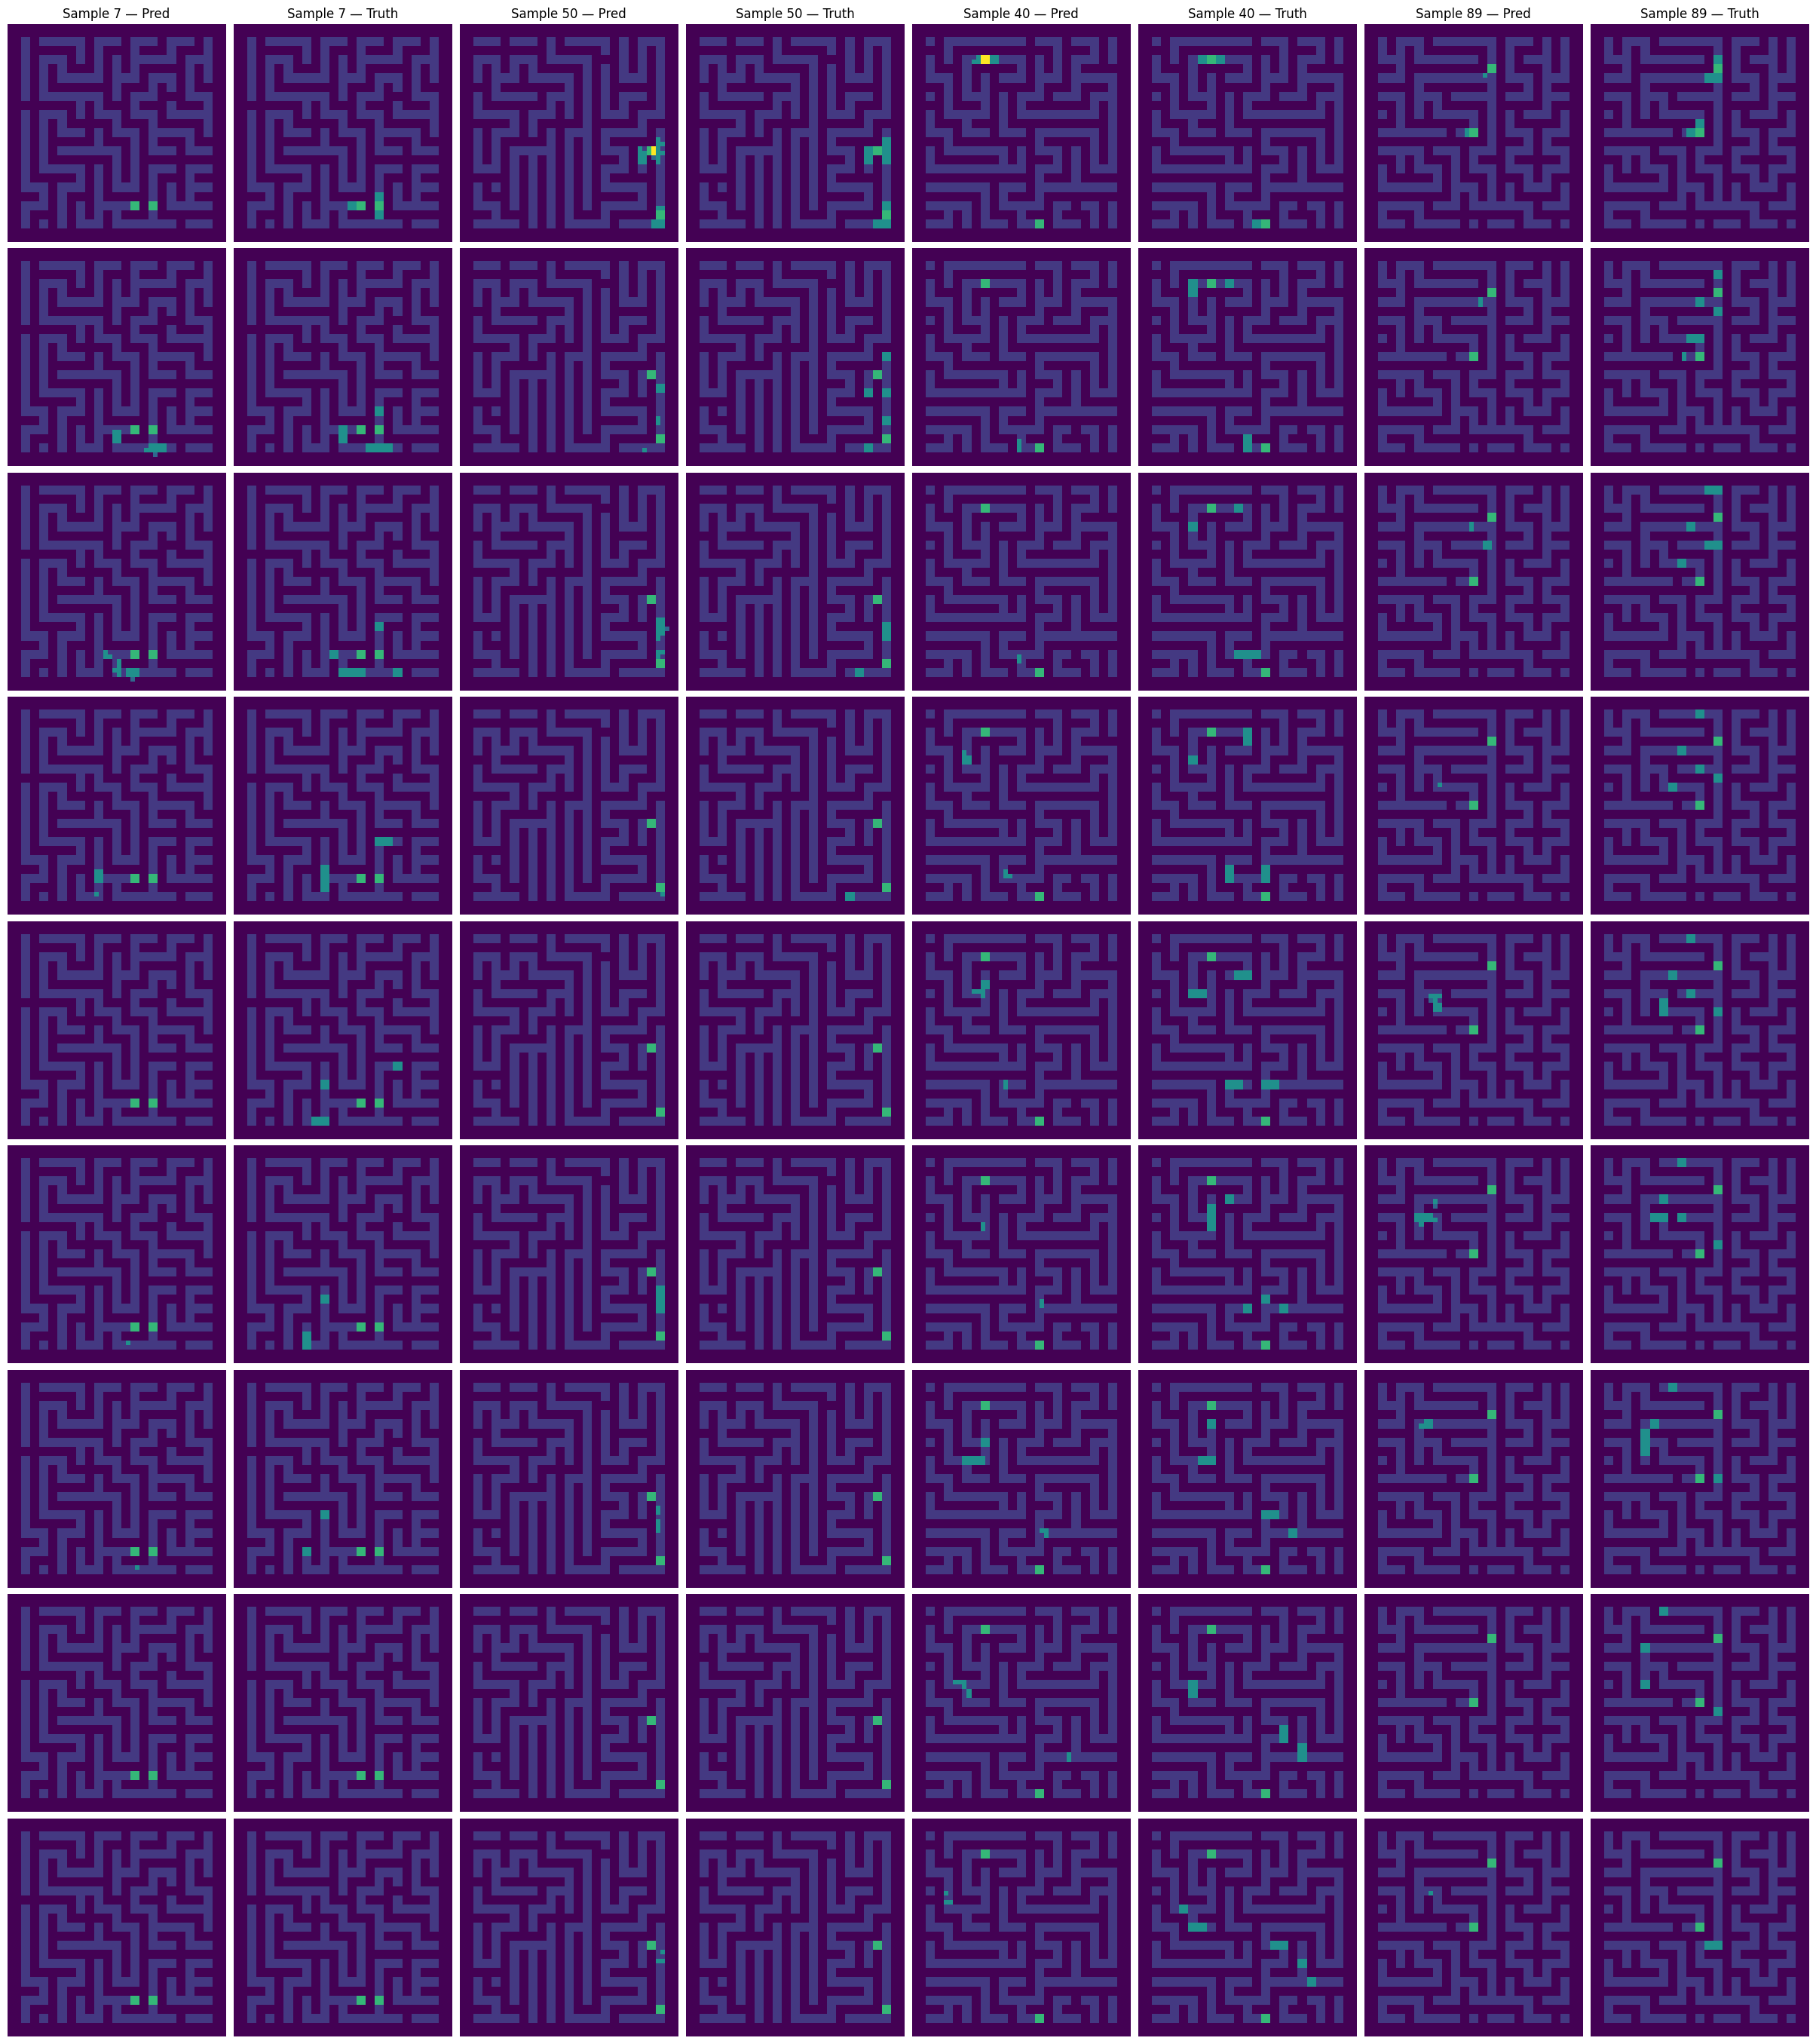

In [189]:
# Choose a few samples to visualize
sample_idxs = [7, 50, 40, 89]   # <-- edit as you like

# sample_idxs = [86, 87, 88, 89]   # <-- edit as you like

# Timesteps to show
# t_range = range(4, 24, 5)
t_range = range(1, 10)
T = len(t_range)
S = len(sample_idxs)

# Collect predictions and truths for each sample & timestep
pred_imgs = [[None]*T for _ in range(S)]
true_imgs = [[None]*T for _ in range(S)]

with torch.no_grad():
    for s_idx, sample_idx in enumerate(sample_idxs):
        # grab a visual "base" and background the same way you were
        test_example = next(iter(testloader))[0][sample_idx]   # [T, C, H, W] or similar; using your original access
        base = test_example[0]
        bg   = test_example[-1]

        for t_i, t in enumerate(t_range):
            # Model prediction at timestep t for this sample
            test_X_subset = test_X[:, t:t+1]           # [N, 1, C, H, W]
            logits = predict_map(model, test_X_subset[sample_idx])   # [H, W] logits
            probs  = torch.sigmoid(logits)                              # [H, W] in [0,1]
            mask   = (probs >= 0.5).float()                             # make numeric for plotting math

            # Compose images: base + 2*mask + 3*bg (pred), and truth similarly
            pred = base + 2*mask + 3*bg
            truth_mask = test_Y[sample_idx, t].float()                   # [H, W]
            truth = base + 2*truth_mask + 3*bg

            pred_imgs[s_idx][t_i]  = pred.detach().cpu()
            true_imgs[s_idx][t_i]  = truth.detach().cpu()

# Global vmin/vmax for consistent scaling across all panels
stack = torch.stack([img for row in (pred_imgs + true_imgs) for imgs in row for img in ([imgs] if torch.is_tensor(imgs) else [])]) \
        if False else torch.stack([im for s in range(S) for t_i in range(T) for im in (pred_imgs[s][t_i], true_imgs[s][t_i])])
vmin, vmax = stack.min().item(), stack.max().item()

# Plot: rows = T timesteps, cols = 2*S (Pred | Truth) for each sample
fig, axs = plt.subplots(T, 2*S, figsize=(3*2*S, 3*T), constrained_layout=True)
axs = np.atleast_2d(axs)

for t_i, t in enumerate(t_range):
    for s_idx, sample_idx in enumerate(sample_idxs):
        c_pred  = 2*s_idx
        c_truth = 2*s_idx + 1

        axs[t_i, c_pred].imshow(pred_imgs[s_idx][t_i],  vmin=vmin, vmax=vmax)
        axs[t_i, c_truth].imshow(true_imgs[s_idx][t_i], vmin=vmin, vmax=vmax)

        # tidy axes
        axs[t_i, c_pred].axis('off')
        axs[t_i, c_truth].axis('off')

        # Titles on top row
        if t_i == 0:
            axs[0, c_pred].set_title(f"Sample {sample_idx} — Pred")
            axs[0, c_truth].set_title(f"Sample {sample_idx} — Truth")

    # y-label per row (timestep)
    axs[t_i, 0].set_ylabel(f"t = {t}")

plt.show()


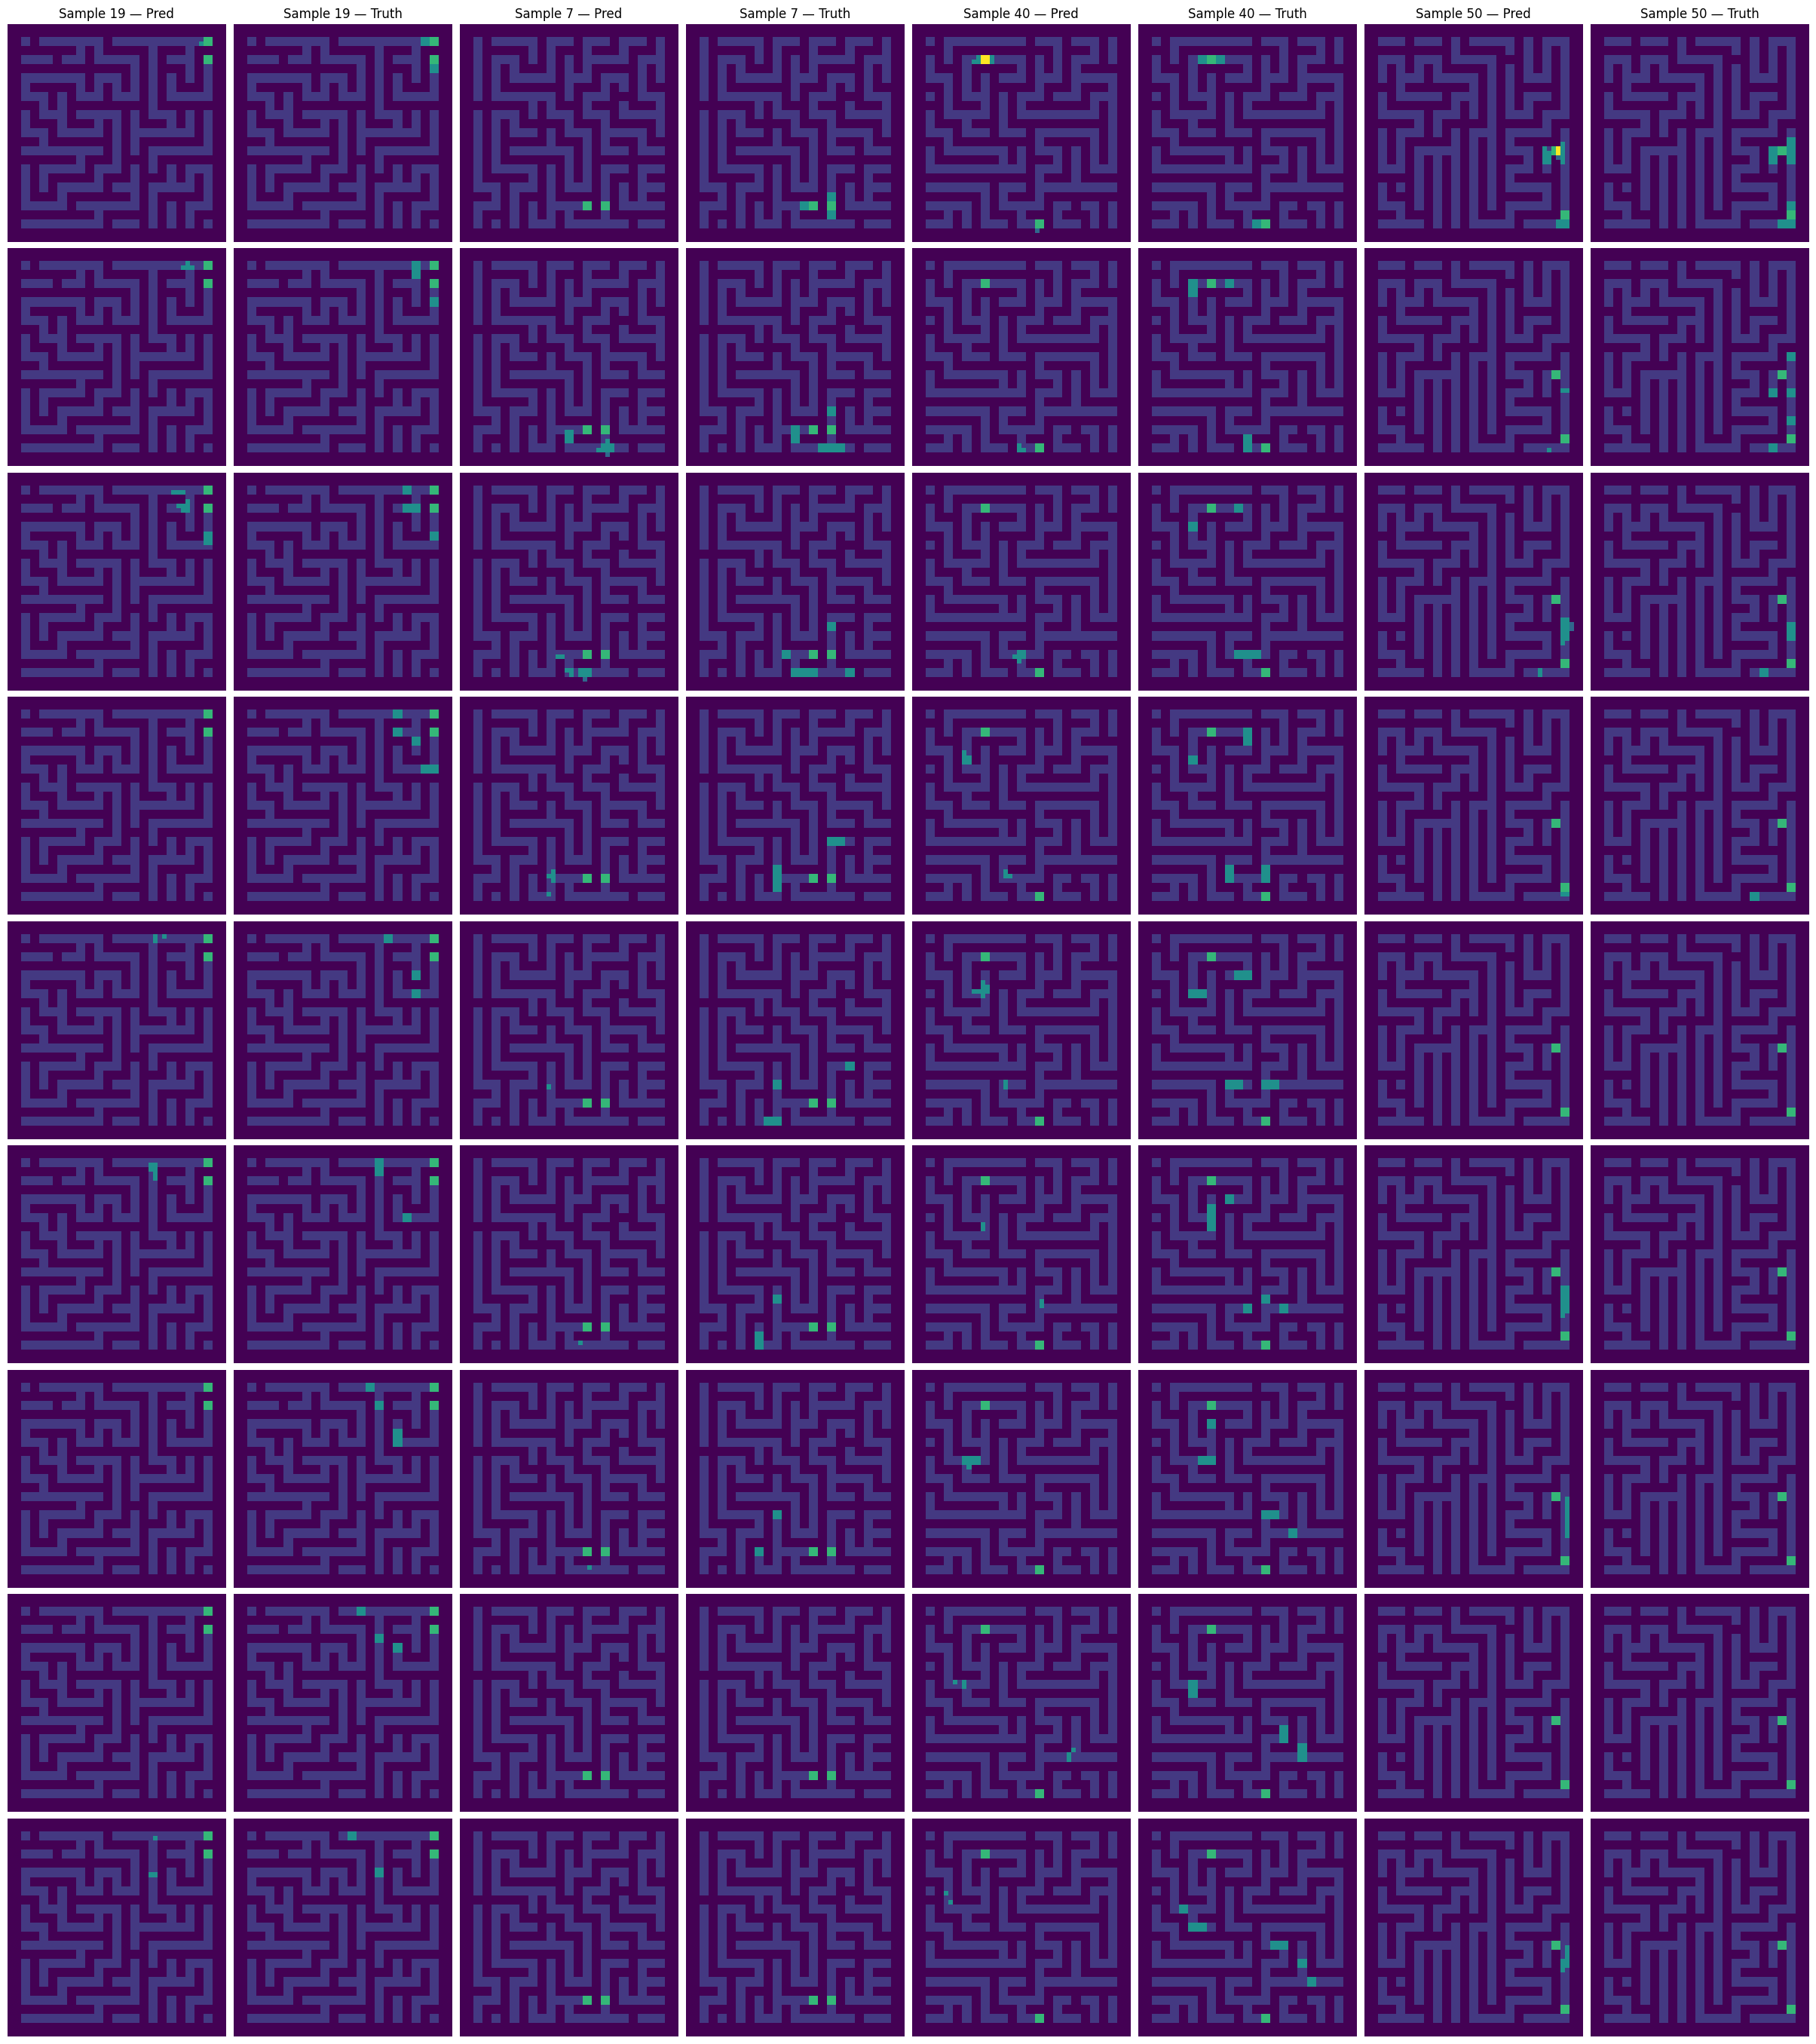

In [180]:
# Choose a few samples to visualize
sample_idxs = [19, 7, 40, 50]   # <-- edit as you like

# Timesteps to show
# t_range = range(4, 24, 5)
t_range = range(1, 10)
T = len(t_range)
S = len(sample_idxs)

# Collect predictions and truths for each sample & timestep
pred_imgs = [[None]*T for _ in range(S)]
true_imgs = [[None]*T for _ in range(S)]

with torch.no_grad():
    for s_idx, sample_idx in enumerate(sample_idxs):
        # grab a visual "base" and background the same way you were
        test_example = next(iter(testloader))[0][sample_idx]   # [T, C, H, W] or similar; using your original access
        base = test_example[0]
        bg   = test_example[-1]

        for t_i, t in enumerate(t_range):
            # Model prediction at timestep t for this sample
            test_X_subset = test_X[:, t:t+1]           # [N, 1, C, H, W]
            logits = predict_map(model, test_X_subset[sample_idx])   # [H, W] logits
            probs  = torch.sigmoid(logits)                              # [H, W] in [0,1]
            mask   = (probs >= 0.5).float()                             # make numeric for plotting math

            # Compose images: base + 2*mask + 3*bg (pred), and truth similarly
            pred = base + 2*mask + 3*bg
            truth_mask = test_Y[sample_idx, t].float()                   # [H, W]
            truth = base + 2*truth_mask + 3*bg

            pred_imgs[s_idx][t_i]  = pred.detach().cpu()
            true_imgs[s_idx][t_i]  = truth.detach().cpu()

# Global vmin/vmax for consistent scaling across all panels
stack = torch.stack([img for row in (pred_imgs + true_imgs) for imgs in row for img in ([imgs] if torch.is_tensor(imgs) else [])]) \
        if False else torch.stack([im for s in range(S) for t_i in range(T) for im in (pred_imgs[s][t_i], true_imgs[s][t_i])])
vmin, vmax = stack.min().item(), stack.max().item()

# Plot: rows = T timesteps, cols = 2*S (Pred | Truth) for each sample
fig, axs = plt.subplots(T, 2*S, figsize=(3*2*S, 3*T), constrained_layout=True)
axs = np.atleast_2d(axs)

for t_i, t in enumerate(t_range):
    for s_idx, sample_idx in enumerate(sample_idxs):
        c_pred  = 2*s_idx
        c_truth = 2*s_idx + 1

        axs[t_i, c_pred].imshow(pred_imgs[s_idx][t_i],  vmin=vmin, vmax=vmax)
        axs[t_i, c_truth].imshow(true_imgs[s_idx][t_i], vmin=vmin, vmax=vmax)

        # tidy axes
        axs[t_i, c_pred].axis('off')
        axs[t_i, c_truth].axis('off')

        # Titles on top row
        if t_i == 0:
            axs[0, c_pred].set_title(f"Sample {sample_idx} — Pred")
            axs[0, c_truth].set_title(f"Sample {sample_idx} — Truth")

    # y-label per row (timestep)
    axs[t_i, 0].set_ylabel(f"t = {t}")

plt.show()


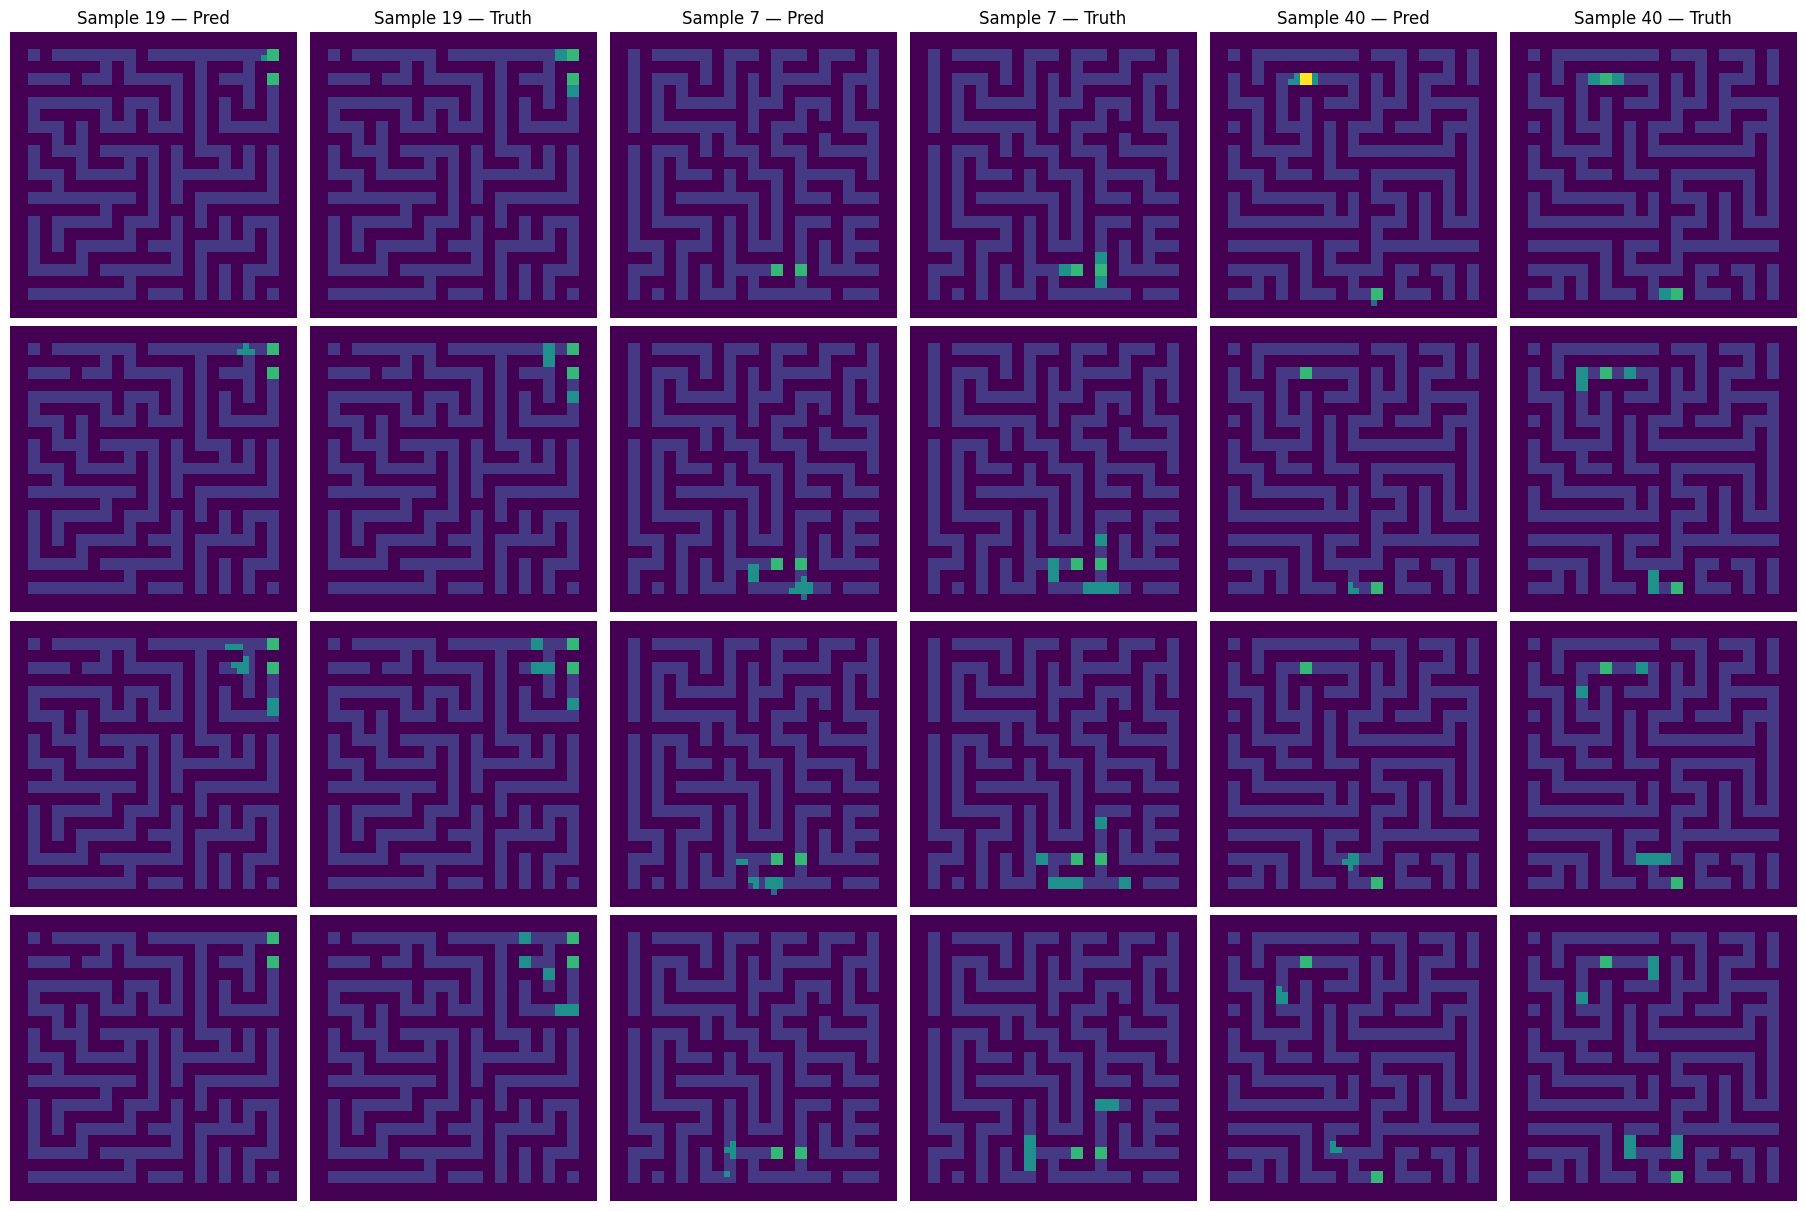

In [179]:
# Choose a few samples to visualize
sample_idxs = [19, 7, 40]   # <-- edit as you like

# Timesteps to show
# t_range = range(4, 24, 5)
t_range = range(1, 5)
T = len(t_range)
S = len(sample_idxs)

# Collect predictions and truths for each sample & timestep
pred_imgs = [[None]*T for _ in range(S)]
true_imgs = [[None]*T for _ in range(S)]

with torch.no_grad():
    for s_idx, sample_idx in enumerate(sample_idxs):
        # grab a visual "base" and background the same way you were
        test_example = next(iter(testloader))[0][sample_idx]   # [T, C, H, W] or similar; using your original access
        base = test_example[0]
        bg   = test_example[-1]

        for t_i, t in enumerate(t_range):
            # Model prediction at timestep t for this sample
            test_X_subset = test_X[:, t:t+1]           # [N, 1, C, H, W]
            logits = predict_map(model, test_X_subset[sample_idx])   # [H, W] logits
            probs  = torch.sigmoid(logits)                              # [H, W] in [0,1]
            mask   = (probs >= 0.5).float()                             # make numeric for plotting math

            # Compose images: base + 2*mask + 3*bg (pred), and truth similarly
            pred = base + 2*mask + 3*bg
            truth_mask = test_Y[sample_idx, t].float()                   # [H, W]
            truth = base + 2*truth_mask + 3*bg

            pred_imgs[s_idx][t_i]  = pred.detach().cpu()
            true_imgs[s_idx][t_i]  = truth.detach().cpu()

# Global vmin/vmax for consistent scaling across all panels
stack = torch.stack([img for row in (pred_imgs + true_imgs) for imgs in row for img in ([imgs] if torch.is_tensor(imgs) else [])]) \
        if False else torch.stack([im for s in range(S) for t_i in range(T) for im in (pred_imgs[s][t_i], true_imgs[s][t_i])])
vmin, vmax = stack.min().item(), stack.max().item()

# Plot: rows = T timesteps, cols = 2*S (Pred | Truth) for each sample
fig, axs = plt.subplots(T, 2*S, figsize=(3*2*S, 3*T), constrained_layout=True)
axs = np.atleast_2d(axs)

for t_i, t in enumerate(t_range):
    for s_idx, sample_idx in enumerate(sample_idxs):
        c_pred  = 2*s_idx
        c_truth = 2*s_idx + 1

        axs[t_i, c_pred].imshow(pred_imgs[s_idx][t_i],  vmin=vmin, vmax=vmax)
        axs[t_i, c_truth].imshow(true_imgs[s_idx][t_i], vmin=vmin, vmax=vmax)

        # tidy axes
        axs[t_i, c_pred].axis('off')
        axs[t_i, c_truth].axis('off')

        # Titles on top row
        if t_i == 0:
            axs[0, c_pred].set_title(f"Sample {sample_idx} — Pred")
            axs[0, c_truth].set_title(f"Sample {sample_idx} — Truth")

    # y-label per row (timestep)
    axs[t_i, 0].set_ylabel(f"t = {t}")

plt.show()


In [120]:
dice_macros

[0.7274605631828308]

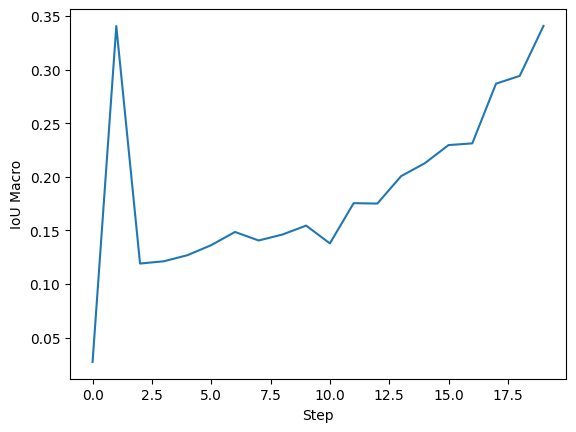

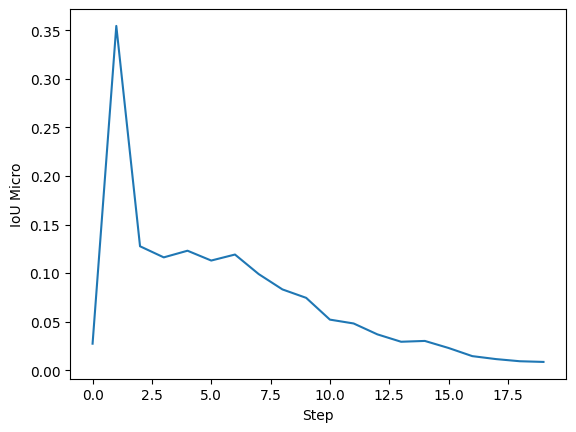

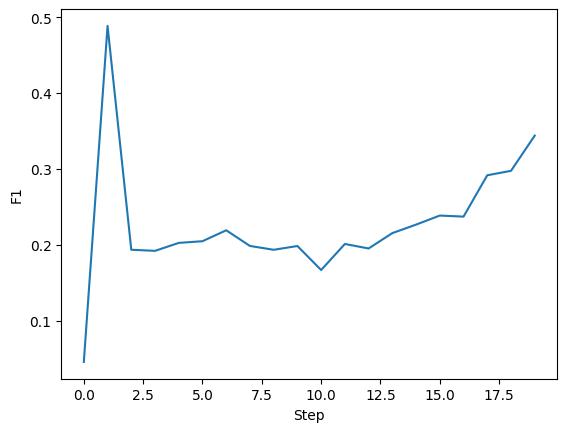

In [171]:
plt.plot(iou_macros)
plt.ylabel("IoU Macro")
plt.xlabel("Step")
plt.show()

plt.plot(iou_micros)
plt.ylabel("IoU Micro")
plt.xlabel("Step")
plt.show()

plt.plot(dice_macros)
plt.ylabel("F1")
plt.xlabel("Step")
plt.show()

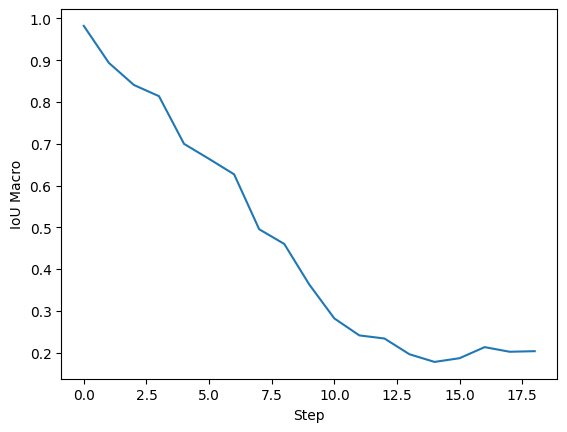

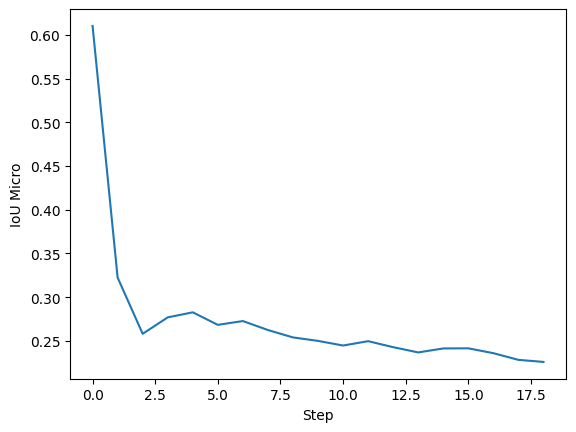

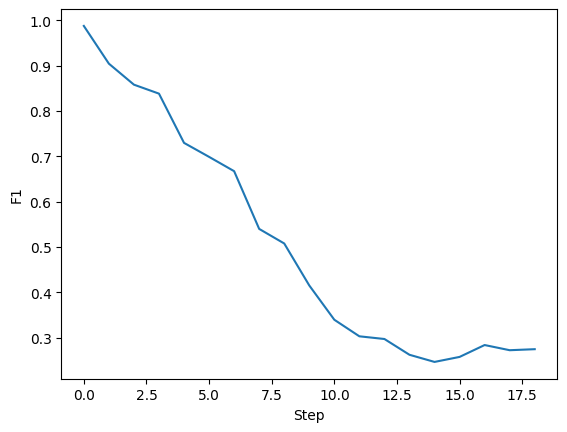

In [100]:
plt.plot(iou_macros)
plt.ylabel("IoU Macro")
plt.xlabel("Step")
plt.show()

plt.plot(iou_micros)
plt.ylabel("IoU Micro")
plt.xlabel("Step")
plt.show()

plt.plot(dice_macros)
plt.ylabel("F1")
plt.xlabel("Step")
plt.show()

In [69]:
pfm = predict_map(model, test_ea[0])

In [ ]:
plt.imshow(test_ea[ea])

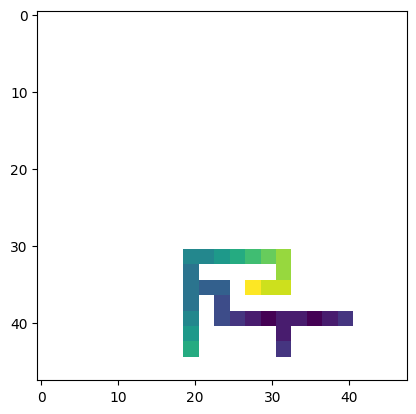

In [70]:
plt.imshow(test_fm[0])

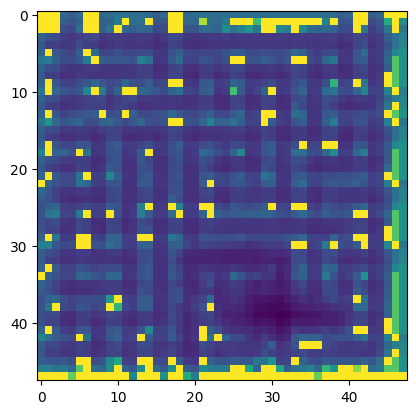

In [72]:
plt.imshow(to_distance(pfm, tau=20))